In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.7 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()

Saving ToothNumber_TaskDataset.zip to ToothNumber_TaskDataset.zip


In [4]:
!unzip ToothNumber_TaskDataset.zip

Archive:  ToothNumber_TaskDataset.zip
   creating: images/
   creating: labels/
  inflating: images/cate8-00059_jpg.rf.d0bd3cb39cc429692abe9c8cf6f9c75e.jpg  
  inflating: images/b879ef2c-20250503-101257822.jpg  
  inflating: images/cate1-00008_jpg.rf.10436fa8d35c0764df5402f3a6f093dc.jpg  
  inflating: images/1c50bda9-20241231-145320490.jpg  
  inflating: images/cate8-00131_jpg.rf.9755ad7a2010d677500a57fe7291285f.jpg  
  inflating: images/b9b8b22f-20240730-123647335.jpg  
  inflating: images/cate2-00127_jpg.rf.aaba4e5e69cf5a828885a05115aa8d11.jpg  
  inflating: images/cate8-00191_jpg.rf.856a6afd259fc24434201fdf1c9b37a0.jpg  
  inflating: images/cate1-00014_jpg.rf.35b346d991cc15ccd3041ca12411ceeb.jpg  
  inflating: images/d1f49454-20240729-105642516.jpg  
  inflating: images/e0d2611b-20240923-112543475.jpg  
  inflating: images/cate5-00073_jpg.rf.35ef24b02f2a62a2073e949f9ddf047f.jpg  
  inflating: images/6d2d78f3-20250507-105238161.jpg  
  inflating: images/3ffe5987-20240830-141140390.jp

In [6]:
!ls

images	labels	sample_data  ToothNumber_TaskDataset.zip


In [7]:
import os
import shutil
import random

base_path = ""

images = os.listdir("images")
random.shuffle(images)

train_size = int(0.8 * len(images))

train_images = images[:train_size]
val_images = images[train_size:]

os.makedirs("dataset/images/train", exist_ok=True)
os.makedirs("dataset/images/val", exist_ok=True)
os.makedirs("dataset/labels/train", exist_ok=True)
os.makedirs("dataset/labels/val", exist_ok=True)

for img in train_images:
    shutil.copy(f"images/{img}", f"dataset/images/train/{img}")
    label = img.replace(".jpg", ".txt")
    shutil.copy(f"labels/{label}", f"dataset/labels/train/{label}")

for img in val_images:
    shutil.copy(f"images/{img}", f"dataset/images/val/{img}")
    label = img.replace(".jpg", ".txt")
    shutil.copy(f"labels/{label}", f"dataset/labels/val/{label}")

print("Dataset split done!")

✅ Dataset split done!


In [8]:
with open("data.yaml", "w") as f:
    f.write("""
train: dataset/images/train
val: dataset/images/val

nc: 32

names: ["0","1","2","3","4","5","6","7","8","9","10","11","12","13","14","15",
        "16","17","18","19","20","21","22","23","24","25","26","27","28","29","30","31"]
""")

print("data.yaml created")

✅ data.yaml created


In [9]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, k

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fef3c7f43b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,

In [10]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

model.predict(
    source="dataset/images/val",
    save=True
)


image 1/100 /content/dataset/images/val/0337fb14-20240822-124747143.jpg: 640x640 2 0s, 1 1, 2 2s, 1 3, 2 4s, 2 5s, 2 6s, 2 7s, 1 9, 2 10s, 2 11s, 2 12s, 2 13s, 2 14s, 2 15s, 2 16s, 1 17, 2 19s, 1 20, 2 21s, 2 22s, 2 23s, 1 24, 2 25s, 1 26, 2 27s, 2 28s, 2 29s, 2 30s, 2 31s, 8.3ms
image 2/100 /content/dataset/images/val/05473f26-20240924-154033777.jpg: 640x640 2 0s, 1 1, 2 2s, 2 3s, 1 4, 2 5s, 1 6, 2 7s, 2 9s, 2 10s, 1 11, 2 13s, 1 14, 2 15s, 2 16s, 2 17s, 2 19s, 2 21s, 2 22s, 1 23, 2 24s, 2 25s, 2 26s, 1 27, 2 28s, 1 29, 2 30s, 2 31s, 7.2ms
image 3/100 /content/dataset/images/val/1c50bda9-20241231-145320490.jpg: 640x640 2 0s, 2 1s, 2 2s, 2 3s, 2 4s, 1 5, 1 6, 2 7s, 2 8s, 1 9, 2 10s, 2 11s, 2 13s, 2 14s, 1 15, 2 16s, 2 19s, 2 20s, 2 21s, 2 23s, 2 24s, 1 26, 2 27s, 1 28, 2 29s, 2 30s, 1 31, 9.2ms
image 4/100 /content/dataset/images/val/2d580460-20240730-115355708.jpg: 640x640 1 0, 1 1, 1 2, 2 4s, 1 5, 2 7s, 2 8s, 2 9s, 2 10s, 2 11s, 1 12, 1 13, 1 14, 2 16s, 2 17s, 2 19s, 2 20s, 3 21s, 1

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: '10', 11: '11', 12: '12', 13: '13', 14: '14', 15: '15', 16: '16', 17: '17', 18: '18', 19: '19', 20: '20', 21: '21', 22: '22', 23: '23', 24: '24', 25: '25', 26: '26', 27: '27', 28: '28', 29: '29', 30: '30', 31: '31'}
 obb: None
 orig_img: array([[[ 70,  70,  70],
         [137, 137, 137],
         [127, 127, 127],
         ...,
         [156, 156, 156],
         [162, 162, 162],
         [ 11,  11,  11]],
 
        [[209, 209, 209],
         [253, 253, 253],
         [250, 250, 250],
         ...,
         [250, 250, 250],
         [255, 255, 255],
         [117, 117, 117]],
 
        [[195, 195, 195],
         [223, 223, 223],
         [225, 225, 225],
         ...,
         [220, 220, 220],
         [222, 222, 222],
         [ 73,  73,  73]],
 
        ...

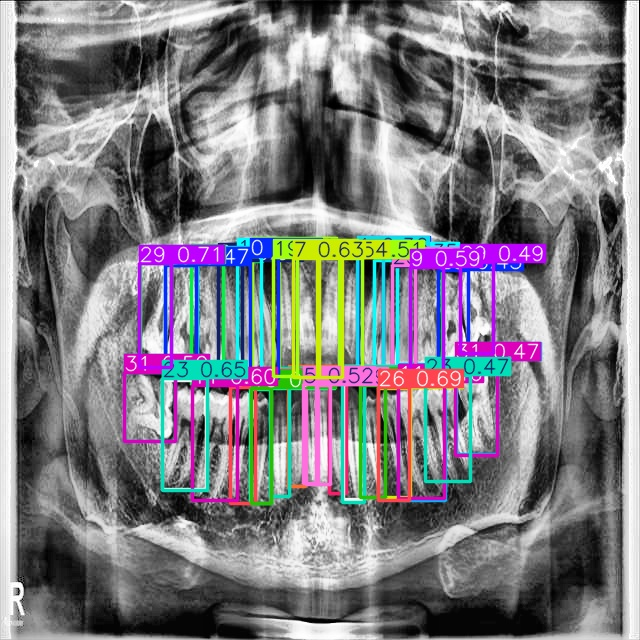

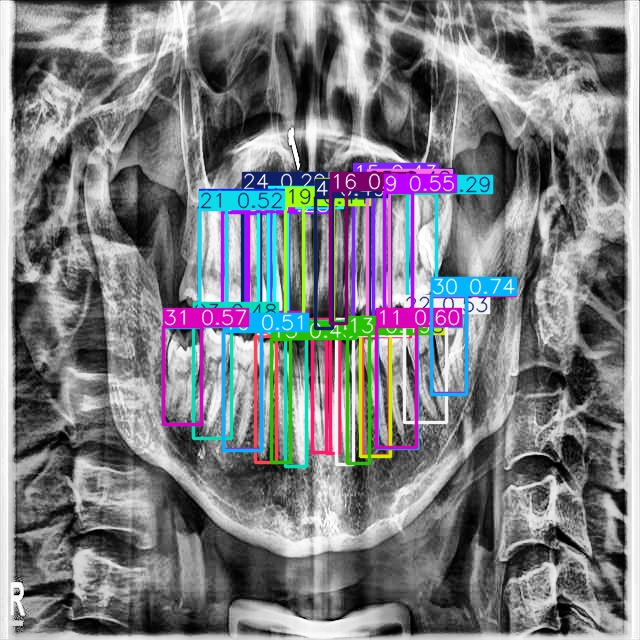

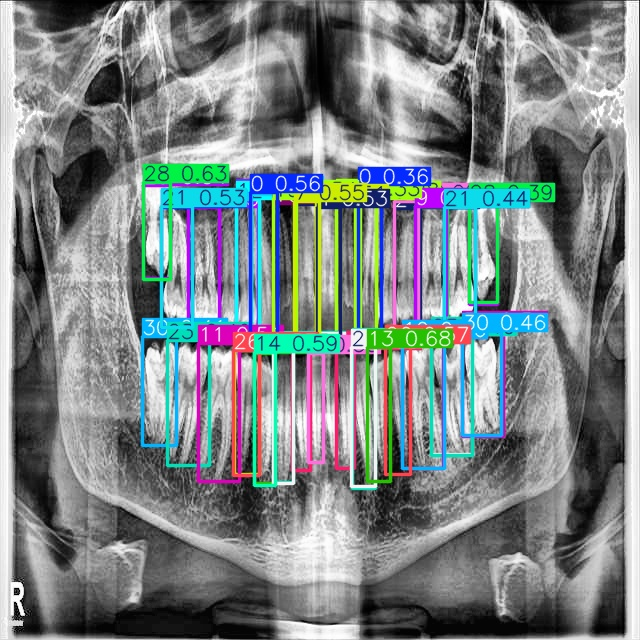

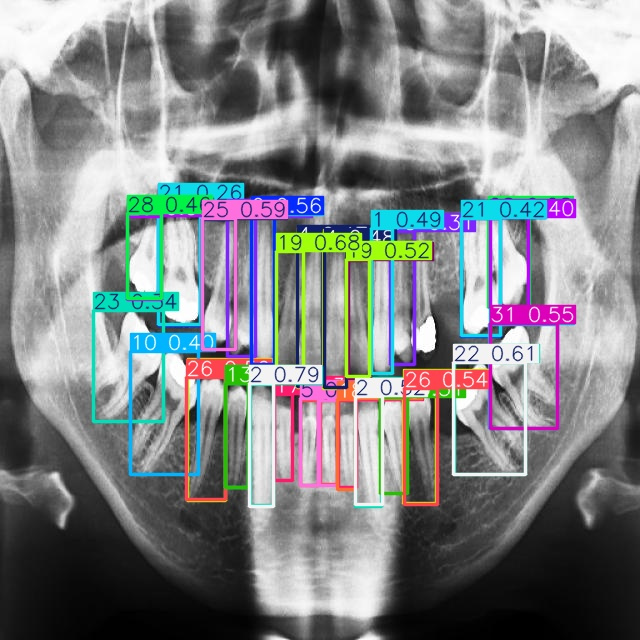

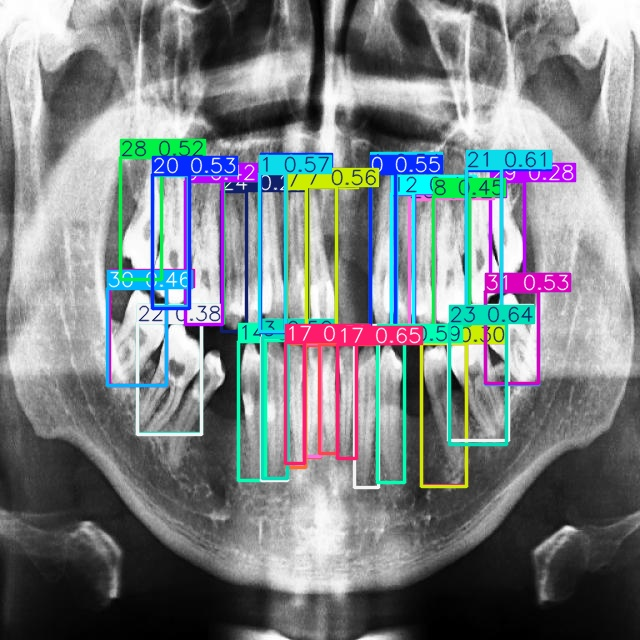

In [11]:
from IPython.display import Image, display
import os

folder = "runs/detect/predict"

for img in os.listdir(folder)[:5]:
    display(Image(filename=os.path.join(folder, img)))

In [12]:
!zip -r final_results.zip runs/
from google.colab import files
files.download("final_results.zip")

  adding: runs/ (stored 0%)
  adding: runs/detect/ (stored 0%)
  adding: runs/detect/train/ (stored 0%)
  adding: runs/detect/train/results.png (deflated 8%)
  adding: runs/detect/train/train_batch1.jpg (deflated 2%)
  adding: runs/detect/train/BoxR_curve.png (deflated 10%)
  adding: runs/detect/train/confusion_matrix.png (deflated 28%)
  adding: runs/detect/train/BoxPR_curve.png (deflated 11%)
  adding: runs/detect/train/args.yaml (deflated 53%)
  adding: runs/detect/train/train_batch1002.jpg (deflated 4%)
  adding: runs/detect/train/labels.jpg (deflated 49%)
  adding: runs/detect/train/results.csv (deflated 61%)
  adding: runs/detect/train/train_batch1001.jpg (deflated 3%)
  adding: runs/detect/train/val_batch1_labels.jpg (deflated 6%)
  adding: runs/detect/train/weights/ (stored 0%)
  adding: runs/detect/train/weights/best.pt (deflated 9%)
  adding: runs/detect/train/weights/last.pt (deflated 9%)
  adding: runs/detect/train/val_batch2_labels.jpg (deflated 6%)
  adding: runs/detect/t

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>